In [22]:
import pandas as pd
import numpy as np
import polars as pl
import re
import ast
import os 
from scipy.stats import norm

# Set working directory
os.chdir("/pool01/projects/abante_lab/")

vcf_path = "ao_prediction_enrollhd_2024/enroll_hd/regulatory_vcfs/"

# Parameters 
chromosome = "15"
enhancer_path = "ao_prediction_enrollhd_2024/genes/gene_cisreg.txt"
predictions_path = f"genomic_llms/borzoi/test_outputs/sed_all_chr/chr{chromosome}.txt.gz"

vcf_file = f"{vcf_path}gwa12345.mis4.9064.hg38.cisreg0.5.mad0.01.chr{chromosome}.vcf"

In [2]:
# Load Enhancer File 
enh = pd.read_csv(enhancer_path, sep="\t")  # uses header from file

# Convert positions to integers
enh["start"] = enh["start"].astype(int)
enh["end"] = enh["end"].astype(int)

# Normalize chromosome naming (remove 'chr')
enh["chrom"] = enh["chrom"].str.replace("chr", "", regex=False)

# Filter to target chromosome only 
enh = enh[enh["chrom"] == chromosome]

# Convert connected_genes to dictionary
enh['connected_genes'] = enh['connected_genes'].apply(
    lambda x: ast.literal_eval(x) if pd.notna(x) else x) # Skip promoters

print(enh.shape)
enh.head()

(3284, 12)


,chrom,target_gene,source,feature name,start,end,score,strand,frame,attributes,genehancer_id,connected_genes
256,15,ABHD17C,GeneHancer,Enhancer,80739540,80740315,0.73,.,.,genehancer_id=GH15F080739;connected_gene=ABHD1...,GH15F080739,"{'ABHD17C': 5.33, 'CEMIP': 0.25, 'PIR33016': 0..."
257,15,ABHD17C,GeneHancer,Enhancer,80673567,80674710,1.21,.,.,genehancer_id=GH15F080673;connected_gene=ABHD1...,GH15F080673,"{'ABHD17C': 0.4, 'RNU6-380P': 0.36}"
258,15,ABHD17C,GeneHancer,Enhancer,80668180,80668329,0.46,.,.,genehancer_id=GH15F080668;connected_gene=CEMIP...,GH15F080668,"{'CEMIP': 10.23, 'RNU6-380P': 0.76, 'ABHD17C':..."
259,15,ABHD17C,GeneHancer,Enhancer,80678388,80686061,0.46,.,.,genehancer_id=GH15F080678;connected_gene=CEMIP...,GH15F080678,"{'CEMIP': 10.71, 'ARNT2': 9.49, 'MIR5572': 9.4..."
260,15,ABHD17C,GeneHancer,Enhancer,80708827,80711215,1.09,.,.,genehancer_id=GH15F080708;connected_gene=CEMIP...,GH15F080708,"{'CEMIP': 10.97, 'RNU6-380P': 10.83, 'ABHD17C'..."


In [3]:
def extract_genes(row):
    return list(row['connected_genes'].keys())

enh["gene_all_ids"] = enh.apply(extract_genes, axis=1)

# Keep only the two specified columns
enh = enh[["feature name", "genehancer_id", "gene_all_ids", "chrom", "start", "end"]]

enh.head()

,feature name,genehancer_id,gene_all_ids,chrom,start,end
256,Enhancer,GH15F080739,"[ABHD17C, CEMIP, PIR33016]",15,80739540,80740315
257,Enhancer,GH15F080673,"[ABHD17C, RNU6-380P]",15,80673567,80674710
258,Enhancer,GH15F080668,"[CEMIP, RNU6-380P, ABHD17C]",15,80668180,80668329
259,Enhancer,GH15F080678,"[CEMIP, ARNT2, MIR5572, ABHD17C, GC15P080692]",15,80678388,80686061
260,Enhancer,GH15F080708,"[CEMIP, RNU6-380P, ABHD17C, PIR33016]",15,80708827,80711215


In [4]:
# Read the VCF file while skipping headers (lines starting with '##')
with open(vcf_file, "r") as f:
    header_lines = [line for line in f if line.startswith("#")]

# Load VCF data into a Polars DataFrame (skipping header lines)
vcf_df = pl.read_csv(vcf_file, comment_prefix="#", separator="\t", has_header=False)

# Assign column names (VCF standard format)
vcf_df = vcf_df.rename({
    "column_1": "CHROM",
    "column_2": "POS",
    "column_3": "ID",
    "column_4": "REF",
    "column_5": "ALT",
    "column_6": "QUAL",
    "column_7": "FILTER",
    "column_8": "INFO",
    "column_9": "FORMAT"
})
vcf_df = vcf_df.with_columns(pl.col("POS").cast(pl.Int64))

# Filter vcf_df for the current chromosome
vcf_df = vcf_df.filter(pl.col("CHROM") == 'chr' + str(chromosome))

In [5]:
vcf_df.head(5)

CHROM,POS,ID,REF,ALT,QUAL,FILTER,INFO,FORMAT,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,…,column_9037,column_9038,column_9039,column_9040,column_9041,column_9042,column_9043,column_9044,column_9045,column_9046,column_9047,column_9048,column_9049,column_9050,column_9051,column_9052,column_9053,column_9054,column_9055,column_9056,column_9057,column_9058,column_9059,column_9060,column_9061,column_9062,column_9063,column_9064,column_9065,column_9066,column_9067,column_9068,column_9069,column_9070,column_9071,column_9072,column_9073
str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,…,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""chr15""",66862731,"""15_67155069_C_T""","""C""","""T""",""".""","""PASS""","""PR""","""GT""","""0/1""","""0/1""","""0/0""","""0/1""","""0/0""","""0/0""","""0/0""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/1""","""0/1""","""0/0""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""",…,"""0/0""","""0/0""","""0/1""","""0/0""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""1/1""","""1/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/1""","""0/1""","""0/0""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0"""
"""chr15""",79979410,"""15_80271752_A_G""","""A""","""G""",""".""","""PASS""","""PR""","""GT""","""0/1""","""0/1""","""0/0""","""0/1""","""0/1""","""0/1""","""1/1""","""0/1""","""0/0""","""0/0""","""1/1""","""0/0""","""0/0""","""0/1""","""0/0""","""1/1""","""0/0""","""0/1""","""0/0""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""0/1""","""0/0""","""0/0""","""0/1""",…,"""1/1""","""1/1""","""0/1""","""1/1""","""0/1""","""0/0""","""0/0""","""0/1""","""0/1""","""0/1""","""0/1""","""0/1""","""0/0""","""0/1""","""0/0""","""0/0""","""1/1""","""0/1""","""0/0""","""0/1""","""0/1""","""1/1""","""0/1""","""0/0""","""0/1""","""0/0""","""0/0""","""0/0""","""0/0""","""0/0""","""0/1""","""1/1""","""0/0""","""0/1""","""1/1""","""0/0""","""1/1"""
"""chr15""",56534027,"""15_56826225_A_G""","""A""","""G""",""".""","""PASS""","""PR""","""GT""","""0/1""","""0/1""","""0/0""","""1/1""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""1/1""","""1/1""","""1/1""","""1/1""","""0/0""","""0/0""","""0/1""","""1/1""","""1/1""","""0/0""","""0/0""","""0/0""","""0/1""","""1/1""","""0/0""","""0/1""","""0/0""","""0/1""","""0/0""",…,"""1/1""","""1/1""","""0/0""","""1/1""","""0/1""","""0/1""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""1/1""","""0/1""","""0/0""","""1/1""","""1/1""","""1/1""","""0/0""","""0/0""","""0/0""","""0/1""","""0/0""","""1/1""","""1/1""","""0/0""","""0/0""","""1/1""","""0/1""","""0/1""","""0/0""","""0/1""","""0/0""","""0/0""","""0/1""","""0/1""","""1/1""","""0/0"""
"""chr15""",84143022,"""15_84811774_A_G""","""A""","""G""",""".""","""PASS""","""PR""","""GT""","""0/0""","""0/1""","""0/0""","""0/1""","""0/1""","""1/1""","""0/0""","""1/1""","""0/0""","""0/1""","""0/1""","""0/1""","""0/0""","""0/0""","""0/1""","""1/1""","""0/1""","""1/1""","""0/1""","""0/1""","""0/0""","""1/1""","""0/1""","""0/0""","""0/0""","""0/0""","""0/1""","""0/0""",…,"""0/0""","""0/0""","""0/1""","""0/1""","""0/1""","""0/1""","""0/1""","""0/0""","""0/1""","""0/1""","""1/1""","""0/1""","""1/1""","""1/1""","""0/1""","""0/0""","""1/1""","""0/0""","""1/1""","""1/1""","""0/0""","""1/1""","""0/1""","""0/1""","""0/1""","""0/0""","""0/1""","""0/1""","""1/1""","""0/1""","""0/1"""

In [44]:
# Load Predictions File 
preds = pl.read_csv(predictions_path, separator="\t")

# Join on 'snp' == 'ID'
preds = preds.join(vcf_df.select(['CHROM', 'POS', 'ID']), left_on='snp', right_on='ID', how='left')

# Extract numeric chrom and pos
preds = preds.with_columns([
    pl.col('CHROM').str.replace('chr', '').cast(pl.Int64).alias('chrom'),
    pl.col('POS').cast(pl.Int64).alias('pos')
])
preds = preds.drop(['CHROM', 'POS'])
preds.head(5)

/tmp/ipykernel_2104571/2510118717.py:5: DeprecationWarning: The default coalesce behavior of left join will change to `False` in the next breaking release. Pass `coalesce=True` to keep the current behavior and silence this warning.
  preds = preds.join(vcf_df.select(['CHROM', 'POS', 'ID']), left_on='snp', right_on='ID', how='left')


snp,gene,alt_allele,tissue,logSED,chrom,pos
str,str,str,str,f64,i64,i64
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Putamen""",-0.00029,15,66862731
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Caudate""",-0.000083,15,66862731
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Putamen""",-0.0016,15,66862731
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Caudate""",-0.00401,15,66862731
"""15_67155069_C_T""","""ENSG00000259437""","""T""","""RNA-seq: Putamen""",-0.000001,15,66862731


In [45]:
# Create a list of tuples with start, end, genehancer_id
intervals = list(zip(enh['start'].to_list(), enh['end'].to_list(), enh['genehancer_id'].to_list()))

# Define a function that returns all genehancer_ids that match the position
def match_enhancer(pos):
    matches = [genehancer_id for start, end, genehancer_id in intervals if start <= pos <= end]
    if matches:
        return matches[0]  # always first match as string
    return None

# Apply this function to each row's pos in preds
preds = preds.with_columns([
    pl.col('pos').apply(match_enhancer).alias('genehancer_id')
])
preds.head(5)

/tmp/ipykernel_2104571/3777832961.py:13: DeprecationWarning: `apply` is deprecated. It has been renamed to `map_elements`.
  pl.col('pos').apply(match_enhancer).alias('genehancer_id')
/tmp/ipykernel_2104571/3777832961.py:12: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  preds = preds.with_columns([


snp,gene,alt_allele,tissue,logSED,chrom,pos,genehancer_id
str,str,str,str,f64,i64,i64,str
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Putamen""",-0.00029,15,66862731,"""GH15F066863"""
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Caudate""",-0.000083,15,66862731,"""GH15F066863"""
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Putamen""",-0.0016,15,66862731,"""GH15F066863"""
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Caudate""",-0.00401,15,66862731,"""GH15F066863"""
"""15_67155069_C_T""","""ENSG00000259437""","""T""","""RNA-seq: Putamen""",-0.000001,15,66862731,"""GH15F066863"""


In [ ]:
# Check if assignation is correct with first example
enh[enh['genehancer_id']=='GH15F066863']

,feature name,genehancer_id,gene_all_ids,chrom,start,end
2265,Enhancer,GH15F066863,"[SNAPC5, LOC105376718, GC15M066899]",15,66862463,66863914


In [47]:
# Check if there are unmatched SNPs
null_count = preds.filter(pl.col('genehancer_id').is_null()).height
print(f"Number of null genehancer_id rows: {null_count}")

Number of null genehancer_id rows: 0


In [ ]:
sigma = 300  # Gaussian std dev from the paper

def compute_weighted_logsed(row):
    enhancer_id = row["genehancer_id"]
    pos = row["pos"]
    logsed = row["logSED"]
    
    # Skip weighting for promoters or null values
    if enhancer_id is None or enhancer_id.startswith("Promoter_"):
        return logsed

    # Get enhancer row from Pandas DataFrame
    gene_enhancers = enh[enh["genehancer_id"] == enhancer_id]
    if gene_enhancers.empty:
        return 0.0

    # Compute enhancer center and Gaussian weight
    enh_row = gene_enhancers.iloc[0]  # taking first match
    center = (enh_row["start"] + enh_row["end"]) / 2
    distance = center - pos
    weight = norm.pdf(distance, loc=0, scale=sigma)

    return logsed * weight

# Use Polars' struct and map_elements to apply row-wise logic
preds = preds.with_columns([
    pl.struct(["genehancer_id", "pos", "logSED"])
      .map_elements(compute_weighted_logsed)
      .alias("weighted_logSED")
])

/tmp/ipykernel_2104571/2043887363.py:26: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  preds = preds.with_columns([


In [49]:
preds

snp,gene,alt_allele,tissue,logSED,chrom,pos,genehancer_id,weighted_logSED
str,str,str,str,f64,i64,i64,str,f64
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Putamen""",-0.00029,15,66862731,"""GH15F066863""",-1.2043e-7
"""15_67155069_C_T""","""ENSG00000137834""","""T""","""RNA-seq: Caudate""",-0.000083,15,66862731,"""GH15F066863""",-3.4691e-8
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Putamen""",-0.0016,15,66862731,"""GH15F066863""",-6.6513e-7
"""15_67155069_C_T""","""ENSG00000277152""","""T""","""RNA-seq: Caudate""",-0.00401,15,66862731,"""GH15F066863""",-0.000002
"""15_67155069_C_T""","""ENSG00000259437""","""T""","""RNA-seq: Putamen""",-0.000001,15,66862731,"""GH15F066863""",-5.9446e-10
…,…,…,…,…,…,…,…,…
"""15_90443140_T_C""","""ENSG00000242498""","""C""","""RNA-seq: Caudate""",0.002392,15,89899908,"""GH15F089898""",1.8216e-7
"""15_31763767_G_A""","""ENSG00000169926""","""A""","""RNA-seq: Putamen""",0.00012,15,31471564,"""GH15F031471""",1.1372e-10
"""15_31763767_G_A""","""ENSG00000169926""","""A""","""RNA-seq: Caudate""",0.0000951,15,31471564,"""GH15F031471""",9.0230e-11


In [50]:
# Filter and print only rows where weighted_logSED > 0.0
zero_rows = preds.filter(pl.col("weighted_logSED") == 0.0)
zero_rows

snp,gene,alt_allele,tissue,logSED,chrom,pos,genehancer_id,weighted_logSED
str,str,str,str,f64,i64,i64,str,f64
"""15_31632691_G_T""","""ENSG00000169926""","""T""","""RNA-seq: Putamen""",0.0002656,15,31340488,"""GH15F031337""",0.0
"""15_31632691_G_T""","""ENSG00000169926""","""T""","""RNA-seq: Caudate""",0.000152,15,31340488,"""GH15F031337""",0.0
"""15_31660361_G_A""","""ENSG00000169926""","""A""","""RNA-seq: Putamen""",0.0000098,15,31368158,"""GH15F031337""",0.0
"""15_31660361_G_A""","""ENSG00000169926""","""A""","""RNA-seq: Caudate""",0.000254,15,31368158,"""GH15F031337""",0.0
"""15_96866320_T_C""","""ENSG00000275443""","""C""","""RNA-seq: Putamen""",-0.000581,15,96323091,"""GH15F096319""",-0.0
…,…,…,…,…,…,…,…,…
"""15_74697122_A_T""","""ENSG00000138629""","""T""","""RNA-seq: Caudate""",-0.000054,15,74404781,"""GH15F074380""",-0.0
"""15_74697122_A_T""","""ENSG00000247240""","""T""","""RNA-seq: Putamen""",0.000235,15,74404781,"""GH15F074380""",0.0
"""15_74697122_A_T""","""ENSG00000247240""","""T""","""RNA-seq: Caudate""",0.0000044,15,74404781,"""GH15F074380""",0.0


In [51]:
enh[enh['genehancer_id']=='GH15F031337']

,feature name,genehancer_id,gene_all_ids,chrom,start,end
22658,Enhancer,GH15F031337,"[KLF13, ENSG00000270055, ENSG00000215302, LOC1...",15,31337226,31373709
24469,Enhancer,GH15F031337,"[KLF13, ENSG00000270055, ENSG00000215302, LOC1...",15,31337226,31373709
87448,Enhancer,GH15F031337,"[KLF13, ENSG00000270055, ENSG00000215302, LOC1...",15,31337226,31373709


In [52]:
# Output 
print(preds[["snp", "gene", "logSED", "weighted_logSED"]])
# preds.to_csv("chr18_weighted_predictions.tsv", sep="\t", index=False)

shape: (116_784, 4)
┌─────────────────┬─────────────────┬───────────┬─────────────────┐
│ snp             ┆ gene            ┆ logSED    ┆ weighted_logSED │
│ ---             ┆ ---             ┆ ---       ┆ ---             │
│ str             ┆ str             ┆ f64       ┆ f64             │
╞═════════════════╪═════════════════╪═══════════╪═════════════════╡
│ 15_67155069_C_T ┆ ENSG00000137834 ┆ -0.00029  ┆ -1.2043e-7      │
│ 15_67155069_C_T ┆ ENSG00000137834 ┆ -0.000083 ┆ -3.4691e-8      │
│ 15_67155069_C_T ┆ ENSG00000277152 ┆ -0.0016   ┆ -6.6513e-7      │
│ 15_67155069_C_T ┆ ENSG00000277152 ┆ -0.00401  ┆ -0.000002       │
│ 15_67155069_C_T ┆ ENSG00000259437 ┆ -0.000001 ┆ -5.9446e-10     │
│ …               ┆ …               ┆ …         ┆ …               │
│ 15_90443140_T_C ┆ ENSG00000242498 ┆ 0.002392  ┆ 1.8216e-7       │
│ 15_31763767_G_A ┆ ENSG00000169926 ┆ 0.00012   ┆ 1.1372e-10      │
│ 15_31763767_G_A ┆ ENSG00000169926 ┆ 0.0000951 ┆ 9.0230e-11      │
│ 15_31763767_G_A ┆ ENSG0000

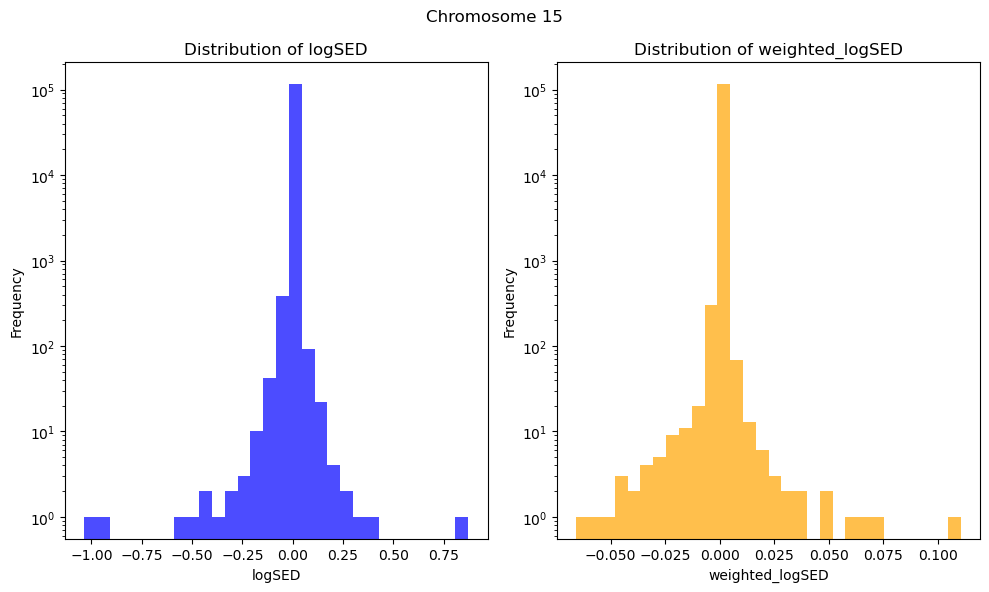

In [53]:
import matplotlib.pyplot as plt

# Plotting the distribution of weighted_logSED and logSED side by side
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1)
plt.hist(preds["logSED"], bins=30, color='blue', alpha=0.7)
plt.title('Distribution of logSED')
plt.xlabel('logSED')
plt.ylabel('Frequency')
plt.yscale('log')
plt.subplot(1, 2, 2)
plt.hist(preds["weighted_logSED"], bins=30, color='orange', alpha=0.7)
plt.title('Distribution of weighted_logSED')
plt.xlabel('weighted_logSED')
plt.ylabel('Frequency')
plt.yscale('log')
plt.suptitle(f'Chromosome {chromosome}')
plt.tight_layout()
plt.show()

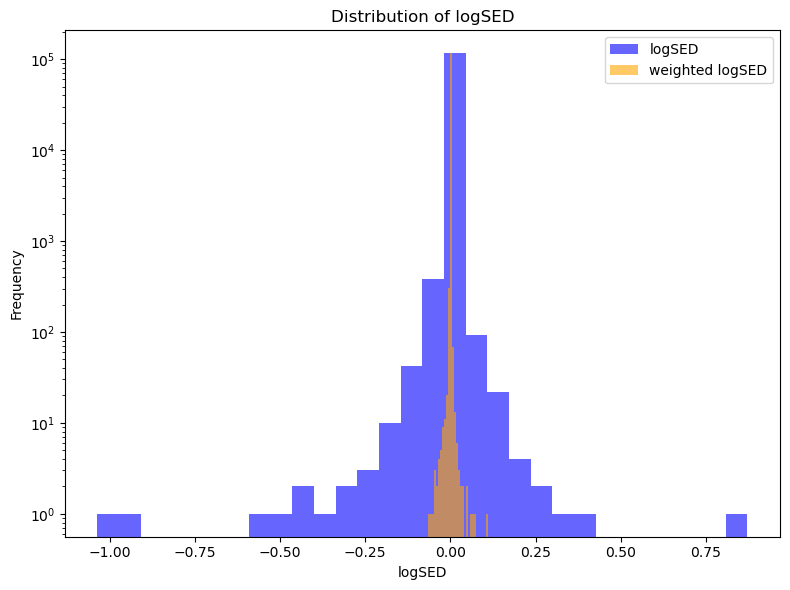

In [54]:
# Plotting the distribution of weighted_logSED and logSED side by side
plt.figure(figsize=(8,6))
plt.hist(preds["logSED"], bins=30, color='blue', label = 'logSED', alpha=0.6)
plt.hist(preds["weighted_logSED"], bins=30, color='orange', label = 'weighted logSED', alpha=0.6)
plt.title('Distribution of logSED')
plt.xlabel('logSED')
plt.ylabel('Frequency')
plt.yscale('log')
plt.legend()
plt.tight_layout()
plt.show()